# pandas e csv

## Resumo

Quase sempre quando formos "ler" um arquivo csv, vamos usar o pandas. É prático e bem eficiente.

## Funcionamento

- Vamos ler um arquivo real, com a Base de Dados de Vendas da Empresa "Contoso"

In [2]:
import pandas as pd

vendas_df = pd.read_csv("Contoso - Vendas - 2017.csv", sep=";")

#não precisa print para exibir no jupyter notebook
# vendas_df[:3]
# vendas_df["Data da Venda"]
# vendas_df[["Numero da Venda", "Data da Venda", "Quantidade Vendida"]] 
# vendas_df[["Numero da Venda", "Data da Venda", "Quantidade Vendida"]][:5]
# vendas_df.info()
vendas_df

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida
0,1,01/01/2017,02/01/2017,1,86,981,2,6825,9,1
1,2,01/01/2017,06/01/2017,5,308,1586,2,18469,9,1
2,3,01/01/2017,01/01/2017,0,294,1444,5,19730,13,1
3,4,01/01/2017,01/01/2017,0,251,1468,5,29326,6,1
4,5,01/01/2017,07/01/2017,6,94,1106,2,22617,4,1
...,...,...,...,...,...,...,...,...,...,...
980637,980638,31/12/2017,31/12/2017,0,194,2490,4,10353,120,0
980638,980639,31/12/2017,06/01/2018,6,32,2488,4,31750,120,0
980639,980640,31/12/2017,03/01/2018,3,210,2511,10,12003,80,0
980640,980641,31/12/2017,31/12/2017,0,53,436,4,25550,39,0


- Tratamento de Dados e Múltiplas Bases


In [26]:
import pandas as pd

produtos_df = pd.read_csv(r"Contoso - Cadastro Produtos.csv", sep=";", encoding="ISO-8859-1")
clientes_df = pd.read_csv(r"Contoso - Clientes.csv", sep=";", encoding="ISO-8859-1")
lojas_df = pd.read_csv(r"Contoso - Lojas.csv", sep=";", encoding="ISO-8859-1")
vendas_df = pd.read_csv(r"Contoso - Vendas - 2017.csv", sep=";", encoding="ISO-8859-1")

#primeira maneira de excluir colunas
# clientes_df = clientes_df.drop(columns=(["Unnamed: 7", "Unnamed: 8", "Unnamed: 9", "Unnamed: 10"]), axis=1) 
clientes_df = clientes_df.rename(columns={"ÿID Cliente": "ID Cliente"})
clientes_df = clientes_df[["ID Cliente", "E-mail"]]
produtos_df = produtos_df.rename(columns={"ÿNome do Produto": "Nome do Produto"})
produtos_df = produtos_df[["ID Produto", "Nome do Produto"]]
lojas_df = lojas_df.rename(columns={"ÿID Loja": "ID Loja"})
lojas_df = lojas_df[["ID Loja", "Nome da Loja"]]

vendas_df = vendas_df.merge(produtos_df, on="ID Produto")
vendas_df = vendas_df.merge(clientes_df, on="ID Cliente")
vendas_df = vendas_df.merge(lojas_df, on="ID Loja")

display(vendas_df)

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Nome do Produto,E-mail,Nome da Loja
0,1,01/01/2017,02/01/2017,1,86,981,2,6825,9,1,A. Datum Advanced Digital Camera M300 Pink,rbrumfieldmy@ameblo.jp,Loja Contoso Austin
1,2,01/01/2017,06/01/2017,5,308,1586,2,18469,9,1,SV DVD 55DVD Storage Binder M56 Black,cshawd4@technorati.com,Loja Contoso North America Reseller
2,3,01/01/2017,01/01/2017,0,294,1444,5,19730,13,1,"The Phone Company Touch Screen Phones 26-2.2"" ...",kgorriekd@bandcamp.com,Loja Contoso Tehran No.2
3,4,01/01/2017,01/01/2017,0,251,1468,5,29326,6,1,Contoso Touch Screen Phones - CRT M11 Black,angela49@adventure-works.com,Loja Contoso Singapore
4,5,01/01/2017,07/01/2017,6,94,1106,2,22617,4,1,Contoso SLR Camera M146 Orange,jacob4@adventure-works.com,Loja Contoso Grand Prairie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980637,980638,31/12/2017,31/12/2017,0,194,2490,4,10353,120,0,Contoso Rubberized Skin BlackBerry E100 White,ocrosson9u@illinois.edu,Loja Contoso Ridgely
980638,980639,31/12/2017,06/01/2018,6,32,2488,4,31750,120,0,Contoso Rubberized Skin BlackBerry E100 Black,victor11@adventure-works.com,Loja Contoso Milliken
980639,980640,31/12/2017,03/01/2018,3,210,2511,10,12003,80,0,Contoso Original K1m Li-Ion Standard Battery E...,mtopaz4@gmpg.org,Loja Contoso Cheshire
980640,980641,31/12/2017,31/12/2017,0,53,436,4,25550,39,0,Adventure Works Desktop PC1.80 ED180 White,lance5@adventure-works.com,Loja Contoso East Troy


- Análise de dados da tabela

E-mail
karen33@adventure-works.com    77
chloe77@adventure-works.com    74
julia43@adventure-works.com    69
josé64@adventure-works.com     68
karen16@adventure-works.com    68
                               ..
hcadwalladergx@slashdot.org     1
ian86@adventure-works.com       1
cvernazza4k@wordpress.com       1
rpeadena0@delicious.com         1
ppitman73@goodreads.com         1
Name: count, Length: 38907, dtype: int64

<Axes: xlabel='E-mail'>

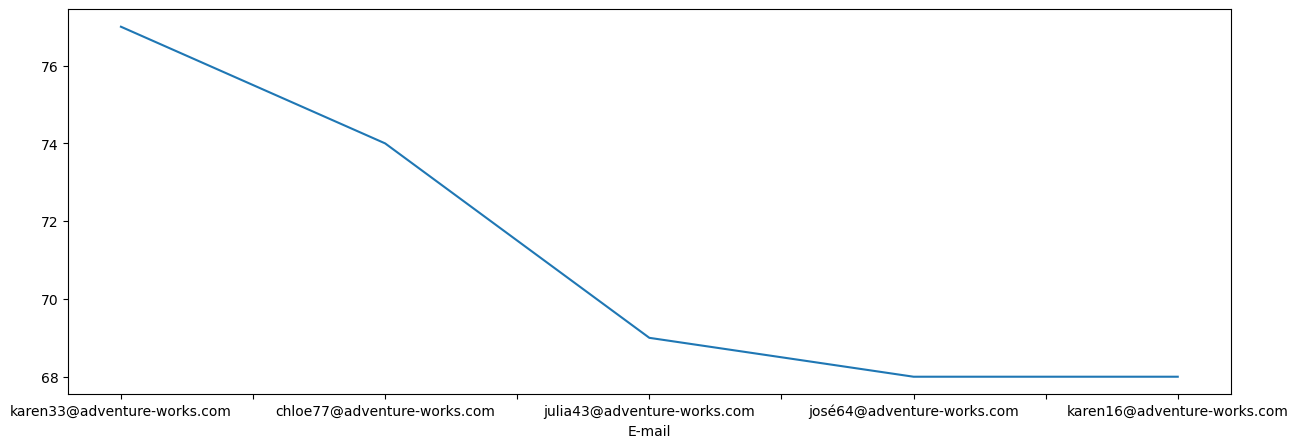

In [4]:
frequencia_clientes = vendas_df["E-mail"].value_counts()
display(frequencia_clientes)
frequencia_clientes[:5].plot(figsize=(15, 5))

,Quantidade Vendida
Nome da Loja,
Loja Contoso Catalog,1029117
Loja Contoso North America Online,701961
Loja Contoso Europe Online,616845
Loja Contoso Asia Online,578458
Loja Contoso North America Reseller,520176
...,...
Loja Contoso Berlin,379
Loja Contoso Paterson,371
Loja Contoso Marseille,370


<Axes: xlabel='Nome da Loja'>

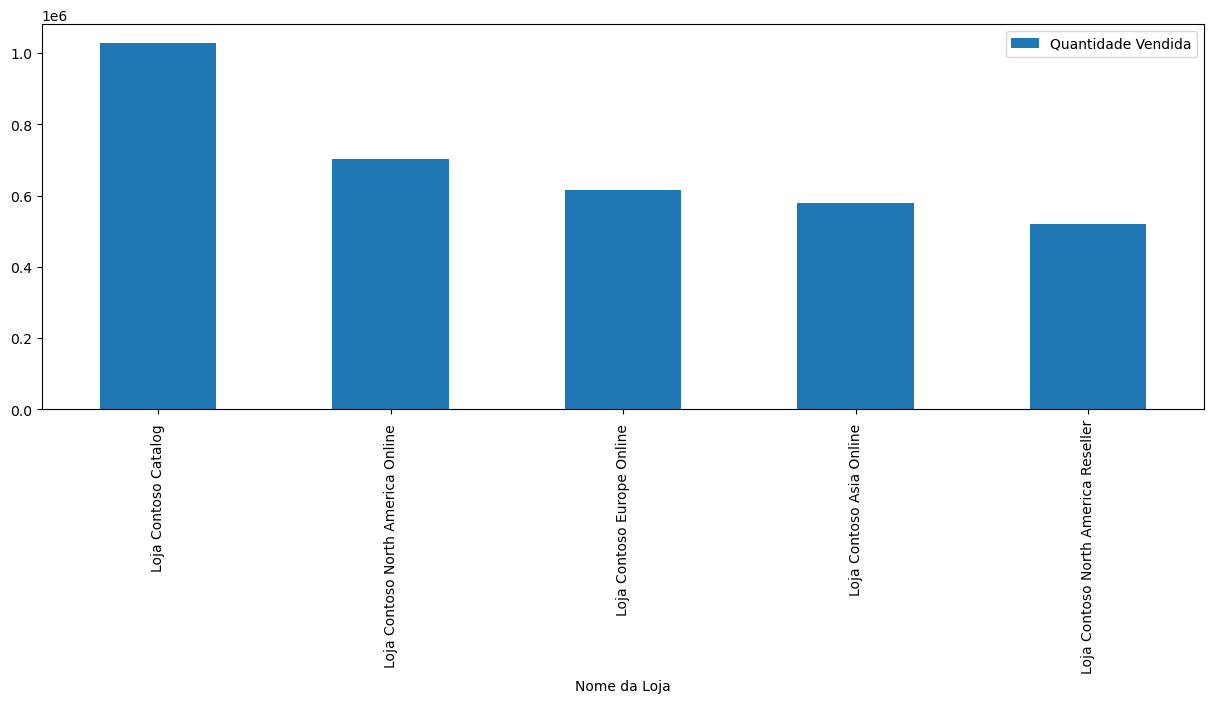

In [8]:
vendas_df = vendas_df.groupby("Nome da Loja").sum()
vendas_df = vendas_df[["Quantidade Vendida"]]
vendas_df = vendas_df.sort_values("Quantidade Vendida", ascending=False)
display(vendas_df)
vendas_df[:5].plot(figsize=(15, 5), kind="bar")

- Adicionando e modificando colunas

In [10]:
vendas_df["Data da Venda"] = pd.to_datetime(vendas_df["Data da Venda"], format='%d/%m/%Y')
vendas_df["Ano da Venda"] = vendas_df["Data da Venda"].dt.year
vendas_df["Mês da Venda"] = vendas_df["Data da Venda"].dt.month
vendas_df["Dia da Venda"] = vendas_df["Data da Venda"].dt.day
display(vendas_df)
vendas_df.info()

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Nome do Produto,E-mail,Nome da Loja,Ano da Venda,Mês da Venda,Dia da Venda
0,1,2017-01-01,02/01/2017,1,86,981,2,6825,9,1,A. Datum Advanced Digital Camera M300 Pink,rbrumfieldmy@ameblo.jp,Loja Contoso Austin,2017,1,1
1,2,2017-01-01,06/01/2017,5,308,1586,2,18469,9,1,SV DVD 55DVD Storage Binder M56 Black,cshawd4@technorati.com,Loja Contoso North America Reseller,2017,1,1
2,3,2017-01-01,01/01/2017,0,294,1444,5,19730,13,1,"The Phone Company Touch Screen Phones 26-2.2"" ...",kgorriekd@bandcamp.com,Loja Contoso Tehran No.2,2017,1,1
3,4,2017-01-01,01/01/2017,0,251,1468,5,29326,6,1,Contoso Touch Screen Phones - CRT M11 Black,angela49@adventure-works.com,Loja Contoso Singapore,2017,1,1
4,5,2017-01-01,07/01/2017,6,94,1106,2,22617,4,1,Contoso SLR Camera M146 Orange,jacob4@adventure-works.com,Loja Contoso Grand Prairie,2017,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980637,980638,2017-12-31,31/12/2017,0,194,2490,4,10353,120,0,Contoso Rubberized Skin BlackBerry E100 White,ocrosson9u@illinois.edu,Loja Contoso Ridgely,2017,12,31
980638,980639,2017-12-31,06/01/2018,6,32,2488,4,31750,120,0,Contoso Rubberized Skin BlackBerry E100 Black,victor11@adventure-works.com,Loja Contoso Milliken,2017,12,31
980639,980640,2017-12-31,03/01/2018,3,210,2511,10,12003,80,0,Contoso Original K1m Li-Ion Standard Battery E...,mtopaz4@gmpg.org,Loja Contoso Cheshire,2017,12,31
980640,980641,2017-12-31,31/12/2017,0,53,436,4,25550,39,0,Adventure Works Desktop PC1.80 ED180 White,lance5@adventure-works.com,Loja Contoso East Troy,2017,12,31


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980642 entries, 0 to 980641
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Numero da Venda       980642 non-null  int64         
 1   Data da Venda         980642 non-null  datetime64[ns]
 2   Data do Envio         980642 non-null  object        
 3   ID Canal              980642 non-null  int64         
 4   ID Loja               980642 non-null  int64         
 5   ID Produto            980642 non-null  int64         
 6   ID Promocao           980642 non-null  int64         
 7   ID Cliente            980642 non-null  int64         
 8   Quantidade Vendida    980642 non-null  int64         
 9   Quantidade Devolvida  980642 non-null  int64         
 10  Nome do Produto       980642 non-null  object        
 11  E-mail                980642 non-null  object        
 12  Nome da Loja          980642 non-null  object        
 13 

-Modificando e consultando valores

In [ ]:
novos_produtos_df = pd.read_csv(r"Contoso - Cadastro Produtos.csv", sep=";", encoding="ISO-8859-1")
novos_produtos_df = novos_produtos_df.set_index("ÿNome do Produto")
display(novos_produtos_df.head())
print(novos_produtos_df.loc["Contoso Wireless Laser Mouse E50 Grey", "Preco Unitario"])
print(novos_produtos_df.iloc[2, 5])

novos_produtos_df.loc["Contoso Wireless Laser Mouse E50 Grey", "Preco Unitario"] = 23
# outra maneira -> novos_produtos_df.loc[novos_produtos_df["ID Produto"] == 873, "Preco Unitario"] = 23
display(novos_produtos_df.head())

,Descricao do Produto,Fabricante,Nome da Marca,Tipo,Custo Unitario,Preco Unitario,ID Produto,ID Subcategoria
ÿNome do Produto,,,,,,,,
Contoso Wireless Laser Mouse E50 Grey,Advanced 2.4 GHz cordless technology makes fre...,"Contoso, Ltd",Contoso,Econômico,"10,69","20,96",873,22
Contoso Optical Wheel OEM PS/2 Mouse E60 Grey,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,879,22
Contoso Optical Wheel OEM PS/2 Mouse E60 Black,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,880,22
Contoso Optical Wheel OEM PS/2 Mouse E60 White,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,881,22
Contoso Optical Wheel OEM PS/2 Mouse E60 Silver,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,882,22


20,96
13


,Descricao do Produto,Fabricante,Nome da Marca,Tipo,Custo Unitario,Preco Unitario,ID Produto,ID Subcategoria
ÿNome do Produto,,,,,,,,
Contoso Wireless Laser Mouse E50 Grey,Advanced 2.4 GHz cordless technology makes fre...,"Contoso, Ltd",Contoso,Econômico,"10,69",23,873,22
Contoso Optical Wheel OEM PS/2 Mouse E60 Grey,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,879,22
Contoso Optical Wheel OEM PS/2 Mouse E60 Black,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,880,22
Contoso Optical Wheel OEM PS/2 Mouse E60 White,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,881,22
Contoso Optical Wheel OEM PS/2 Mouse E60 Silver,"PS/2 mouse, 6 feet mouse cable","Contoso, Ltd",Contoso,Econômico,"6,63",13,882,22


 - Criar barra de progresso

In [28]:
from tqdm import tqdm

pbar = tqdm(total=len(vendas_df), position=0, leave=True)

for i, id_loja in enumerate(vendas_df['ID Loja']):
    pbar.update()
    if id_loja == 222:
        vendas_df.loc[i, "Quantidade Devolvida"] += 1

display(vendas_df)

100%|█████████▉| 979474/980642 [00:06<00:00, 49208.59it/s] 

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Nome do Produto,E-mail,Nome da Loja
0,1,01/01/2017,02/01/2017,1,86,981,2,6825,9,1,A. Datum Advanced Digital Camera M300 Pink,rbrumfieldmy@ameblo.jp,Loja Contoso Austin
1,2,01/01/2017,06/01/2017,5,308,1586,2,18469,9,1,SV DVD 55DVD Storage Binder M56 Black,cshawd4@technorati.com,Loja Contoso North America Reseller
2,3,01/01/2017,01/01/2017,0,294,1444,5,19730,13,1,"The Phone Company Touch Screen Phones 26-2.2"" ...",kgorriekd@bandcamp.com,Loja Contoso Tehran No.2
3,4,01/01/2017,01/01/2017,0,251,1468,5,29326,6,1,Contoso Touch Screen Phones - CRT M11 Black,angela49@adventure-works.com,Loja Contoso Singapore
4,5,01/01/2017,07/01/2017,6,94,1106,2,22617,4,1,Contoso SLR Camera M146 Orange,jacob4@adventure-works.com,Loja Contoso Grand Prairie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980637,980638,31/12/2017,31/12/2017,0,194,2490,4,10353,120,0,Contoso Rubberized Skin BlackBerry E100 White,ocrosson9u@illinois.edu,Loja Contoso Ridgely
980638,980639,31/12/2017,06/01/2018,6,32,2488,4,31750,120,0,Contoso Rubberized Skin BlackBerry E100 Black,victor11@adventure-works.com,Loja Contoso Milliken
980639,980640,31/12/2017,03/01/2018,3,210,2511,10,12003,80,0,Contoso Original K1m Li-Ion Standard Battery E...,mtopaz4@gmpg.org,Loja Contoso Cheshire
980640,980641,31/12/2017,31/12/2017,0,53,436,4,25550,39,0,Adventure Works Desktop PC1.80 ED180 White,lance5@adventure-works.com,Loja Contoso East Troy


100%|██████████| 980642/980642 [00:20<00:00, 49208.59it/s]